# Beam Deflection Analysis - Theory and Derivations

## 1. The Physical Problem

We have a **simply supported beam** (supported at both ends, free to rotate) with point loads applied at various locations. We want to find:
- How much the beam deflects (bends downward)
- Where the maximum deflection occurs
- Whether it exceeds allowable limits

## 2. Deflection Formula for a Point Load

### 2.1 The Equation

For a simply supported beam of length $L$ with a point load $P$ at distance $a$ from the left support, the deflection at any position $x$ is:

**For $x \leq a$ (before the load):**

$$y(x) = \frac{Pb x}{6LEI}(L^2 - b^2 - x^2)$$

**For $x > a$ (after the load):**

$$y(x) = \frac{Pa(L-x)}{6LEI}[L^2 - a^2 - (L-x)^2]$$

Where:
- $y(x)$ = deflection at position $x$ (negative means downward)
- $P$ = point load magnitude (N or kN)
- $a$ = distance of load from left support (m)
- $b = L - a$ = distance of load from right support (m)
- $L$ = total beam length (m)
- $E$ = Young's modulus (material stiffness, Pa)
- $I$ = moment of inertia (beam cross-section property, m⁴)

### 2.2 Physical Meaning

The equation tells us:
- Deflection is **proportional to load** $P$ (double the load → double the deflection)
- Deflection is **inversely proportional to stiffness** $EI$ (stiffer beam → less deflection)
- Deflection depends on **where you measure** ($x$) and **where the load is** ($a$)
- Maximum deflection is NOT necessarily at midspan if load is off-center

### 2.3 Derivation Overview (Optional)

This formula comes from solving the **beam bending equation**:

$$EI \frac{d^4y}{dx^4} = w(x)$$

Where $w(x)$ is the distributed load. For a point load, we integrate this equation four times with appropriate boundary conditions:
- At supports: $y(0) = 0$ and $y(L) = 0$ (no deflection)
- At supports: $M(0) = 0$ and $M(L) = 0$ (no moment, free rotation)

The derivation involves calculus (integration) but results in the closed-form equations above.

## 3. Principle of Superposition

### 3.1 The Concept

**Superposition Principle**: For linear elastic systems, the total deflection from multiple loads is the **sum** of deflections from each load acting individually.

$$y_{total}(x) = y_1(x) + y_2(x) + y_3(x) + ...$$

### 3.2 Why It Works

The beam equation is **linear** in deflection $y$:
- No $y^2$ or $y^3$ terms
- No products like $y \cdot y'$
- Just $y$ and its derivatives

This linearity means:
- If load $P_1$ causes deflection $y_1$
- And load $P_2$ causes deflection $y_2$
- Then loads $P_1 + P_2$ cause deflection $y_1 + y_2$

### 3.3 Example

For two loads:
- Load 1: $P_1 = 5$ kN at $a_1 = 1.5$ m
- Load 2: $P_2 = 8$ kN at $a_2 = 4.0$ m

At position $x = 3.0$ m:
```
y_total(3.0) = y_from_load1(3.0) + y_from_load2(3.0)
```

We calculate each deflection separately using the formula, then add them!

### 3.4 Practical Implementation
```python
# Initialize deflection
deflections = [0.0] * n_points

# Add contribution from each load
for position_x in x_positions:
    for load_pos, load_mag in loads:
        deflection_from_this_load = formula(position_x, load_pos, load_mag, ...)
        deflections[i] += deflection_from_this_load
```

## 4. Finding Maximum Deflection Using Finite Differences

### 4.1 The Problem

We have deflection values at discrete points: $y_0, y_1, y_2, ..., y_n$

We need to find where deflection is maximum. At maximum, the **slope must be zero**:

$$\frac{dy}{dx} = 0$$

### 4.2 Finite Difference Approximation of Derivatives

**Calculus Definition** of derivative:

$$\frac{dy}{dx} = \lim_{\Delta x \to 0} \frac{y(x + \Delta x) - y(x)}{\Delta x}$$

**Finite Difference Approximation** (for small but finite $\Delta x$):

$$\frac{dy}{dx} \approx \frac{y_{i+1} - y_i}{\Delta x}$$

This is called the **forward difference** formula.

### 4.3 Types of Finite Differences

**Forward Difference** (uses points ahead):
$$\frac{dy}{dx}\bigg|_i \approx \frac{y_{i+1} - y_i}{\Delta x}$$

**Backward Difference** (uses points behind):
$$\frac{dy}{dx}\bigg|_i \approx \frac{y_i - y_{i-1}}{\Delta x}$$

**Central Difference** (more accurate, uses both):
$$\frac{dy}{dx}\bigg|_i \approx \frac{y_{i+1} - y_{i-1}}{2\Delta x}$$

### 4.4 Visual Understanding
```
         y[i+1]
           ●
          /
         /  ← slope ≈ (y[i+1] - y[i])/Δx
        /
       ●
     y[i]
```

If we have many points close together, this approximation becomes very accurate!

### 4.5 Finding the Maximum

At maximum deflection, slope changes from **negative to positive** (for downward deflection):
```
Before max:  slope < 0  (going down)
At max:      slope ≈ 0  (flat, turning point)
After max:   slope > 0  (going up)
```

**Algorithm:**
1. Calculate slope at each point using finite differences
2. Find where slope is closest to zero
3. That's where maximum deflection occurs!
```python
slopes = []
for i in range(len(deflections) - 1):
    dx = x_positions[i+1] - x_positions[i]
    slope = (deflections[i+1] - deflections[i]) / dx
    slopes.append(slope)

# Find point with minimum slope magnitude (closest to zero)
# Or simply find minimum deflection value
max_deflection_index = deflections.index(min(deflections))
```

### 4.6 Why Not Just Find Minimum Value?

You're right - we can! For deflection curves, finding `min(deflections)` gives the maximum downward deflection.

But computing the **slope** teaches us:
- How finite differences work (foundation for numerical methods)
- Visualizing where slope = 0 confirms the maximum location
- Later problems (stress analysis, vibrations) need derivatives explicitly

### 4.7 Accuracy Considerations

Finite difference accuracy depends on **step size** $\Delta x$:
- Smaller $\Delta x$ → more accurate
- But too small → rounding errors
- Typical: 50-200 points along beam length

**Error** in finite difference:
$$\text{Error} = O(\Delta x) \text{ for forward/backward}$$
$$\text{Error} = O(\Delta x^2) \text{ for central difference}$$

This means halving $\Delta x$ reduces error by ~2× (forward) or ~4× (central).

## 5. Serviceability Check (L/360 Criterion)

### 5.1 Building Code Requirement

Maximum deflection should not exceed:

$$\delta_{max} \leq \frac{L}{360}$$

This is a **serviceability limit** to prevent:
- Visible sagging
- Cracking of finishes (plaster, tiles)
- User discomfort
- Vibration issues

### 5.2 Example

For $L = 6$ m:
$$\delta_{allowable} = \frac{6000 \text{ mm}}{360} = 16.67 \text{ mm}$$

If calculated deflection = 6.34 mm < 16.67 mm → **PASS** ✓

## 6. Why Asymmetric Loads Create Off-Center Deflection

### 6.1 Symmetry Argument

**Symmetric case** (equal loads at equal distances from center):
- Load at 2m: 5 kN
- Load at 4m: 5 kN (6m beam)
- Maximum deflection at center (3m) by symmetry

**Asymmetric case** (unequal loads or positions):
- Load at 1.5m: 5 kN
- Load at 4.0m: 8 kN
- Heavier load "pulls" maximum toward itself
- Maximum at ~3.15m (closer to the 8 kN load)

### 6.2 Influence Lines

Each load creates a deflection "shape." The total shape is the sum. The 8 kN load at 4.0m creates a larger deflection contribution that shifts the peak rightward.

## 7. Data Structures in the Code

### 7.1 Why Different Types?

**Tuples** for loads: `(1.5, 5000)`
- Immutable: Load position and magnitude don't change
- Paired data: Always position + magnitude together
- Access: `loads[0][0]` = position, `loads[0][1]` = magnitude

**Dictionary** for beam: `{'L': 6.0, 'E': 200e9, 'I': 8.33e-6}`
- Named access: `beam['L']` is clearer than `beam[0]`
- Self-documenting: Know what each value means
- Flexible: Easy to add properties later

**Lists** for computation: `deflections = [0.0] * n`
- Mutable: Need to update values during calculation
- Indexed: Access by position `deflections[i]`
- Dynamic: Can compute, modify, extend

## 8. Summary

**Key Equations:**
1. Point load deflection: $y(x) = \frac{Pbx}{6LEI}(L^2 - b^2 - x^2)$ for $x \leq a$
2. Superposition: $y_{total} = \sum y_i$
3. Finite difference: $\frac{dy}{dx} \approx \frac{y_{i+1} - y_i}{\Delta x}$
4. Serviceability: $\delta_{max} \leq \frac{L}{360}$

**Key Concepts:**
- **Superposition**: Add deflections from each load independently
- **Finite differences**: Approximate derivatives using nearby points
- **Maximum location**: Where slope = 0 (or find minimum deflection directly)
- **Data structures**: Use appropriate types for different purposes

**Engineering Reality:**
This is how real structural engineers analyze beams! More complex cases use finite element software, but the principles (superposition, deflection limits) remain the same.

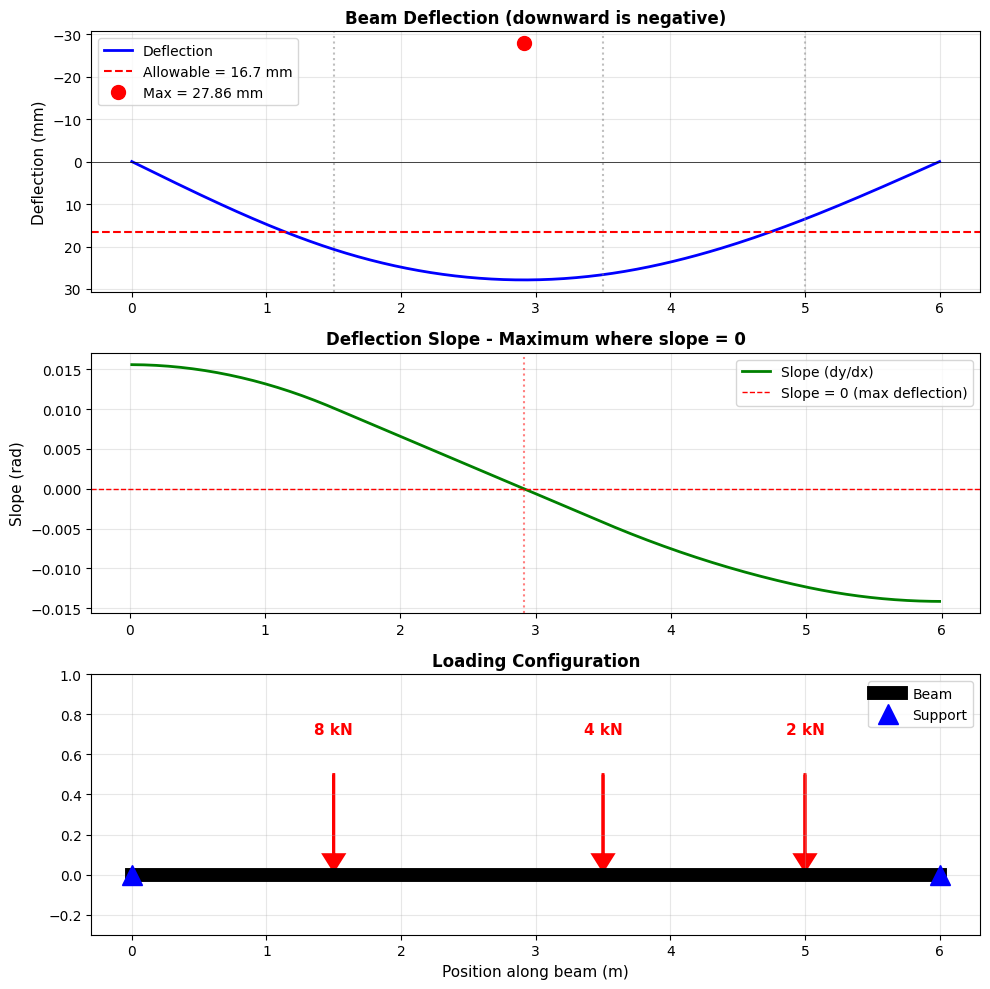

In [5]:
import matplotlib.pyplot as plt

# BEAM PROPERTIES (dictionary)
beam = {
    'L': 6.0,        # length (m)
    'E': 200e9,      # Young's modulus (Pa)
    'I': 8.33e-6,    # moment of inertia (m^4)
}

# POINT LOADS (tuples: position and magnitude)
loads = (
    (1.5, 8000),     # 5 kN at 1.5m (HVAC unit)
    (3.5, 4000),     # 8 kN at 4.0m (equipment)
    (5, 2000),
)

# CALCULATE DEFLECTION using beam formula (superposition)
def deflection_point_load(x, P, a, L, E, I):
    """Deflection at x due to point load P at position a"""
    b = L - a
    if x <= a:
        return (P * b * x / (6 * L * E * I)) * (L**2 - b**2 - x**2)
    else:
        return (P * a * (L - x) / (6 * L * E * I)) * (L**2 - a**2 - (L - x)**2)

# CREATE POSITION LIST and compute deflections
n_points = 201
x_positions = [i * beam['L'] / (n_points - 1) for i in range(n_points)]
deflections = [0.0] * n_points  # initialize list

# Add deflection from each load (superposition)
for i, x in enumerate(x_positions):
    for load_pos, load_mag in loads:
        deflections[i] += deflection_point_load(x, load_mag, load_pos,
                                                beam['L'], beam['E'], beam['I'])

# FIND MAXIMUM using finite difference derivative
# dy/dx ≈ (y[i+1] - y[i]) / dx
slopes = []
for i in range(len(deflections) - 1):
    dx = x_positions[i+1] - x_positions[i]
    slope = (deflections[i+1] - deflections[i]) / dx
    slopes.append(slope)

# Find where slope changes from negative to positive (minimum deflection = max downward)
max_deflection = 0
max_location = 0
for i in range(len(deflections)):
    if abs(deflections[i]) > max_deflection:
        max_deflection = abs(deflections[i])
        max_location = x_positions[i]

# RESULTS dictionary
results = {
    'max_deflection_mm': max_deflection * 1000,
    'max_location_m': max_location,
    'allowable_mm': beam['L'] / 360 * 1000,
    'status': 'PASS' if max_deflection < beam['L']/360 else 'FAIL'
}

# PLOT RESULTS
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10))

# 1. DEFLECTION DIAGRAM
y_mm = [y * 1000 for y in deflections]  # convert to mm
ax1.plot(x_positions, y_mm, 'b-', linewidth=2, label='Deflection')
ax1.axhline(0, color='k', linewidth=0.5)
ax1.axhline(results['allowable_mm'], color='r', linestyle='--',
            label=f'Allowable = {results["allowable_mm"]:.1f} mm')
ax1.plot(max_location, -max_deflection*1000, 'ro', markersize=10,
         label=f'Max = {results["max_deflection_mm"]:.2f} mm')

for pos, load in loads:
    ax1.axvline(pos, color='gray', alpha=0.5, linestyle=':')

ax1.set_ylabel('Deflection (mm)', fontsize=11)
ax1.set_title('Beam Deflection (downward is negative)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.invert_yaxis()

# 2. SLOPE DIAGRAM (finite difference derivative)
x_slopes = [x_positions[i] + (x_positions[i+1] - x_positions[i])/2 for i in range(len(slopes))]
ax2.plot(x_slopes, slopes, 'g-', linewidth=2, label='Slope (dy/dx)')
ax2.axhline(0, color='r', linestyle='--', linewidth=1, label='Slope = 0 (max deflection)')
ax2.axvline(max_location, color='r', alpha=0.5, linestyle=':')
ax2.set_ylabel('Slope (rad)', fontsize=11)
ax2.set_title('Deflection Slope - Maximum where slope = 0', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. BEAM SCHEMATIC
ax3.plot([0, beam['L']], [0, 0], 'k-', linewidth=10, label='Beam')
ax3.plot(0, 0, '^', markersize=15, color='blue', label='Support')
ax3.plot(beam['L'], 0, '^', markersize=15, color='blue')

for pos, load in loads:
    ax3.arrow(pos, 0.5, 0, -0.4, head_width=0.15, head_length=0.08,
              fc='red', ec='red', linewidth=2)
    ax3.text(pos, 0.7, f'{load/1000:.0f} kN', ha='center',
             fontsize=11, fontweight='bold', color='red')

ax3.set_xlim(-0.3, beam['L'] + 0.3)
ax3.set_ylim(-0.3, 1)
ax3.set_xlabel('Position along beam (m)', fontsize=11)
ax3.set_title('Loading Configuration', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()